In [ ]:
# This runs all the ablation studies in series and saves the models as pk files in the `partial_models` folder.
# NOTE that this will require SOME DAYS to run. Be careful and patient. Or simply trust us that the results are correct and skip to the next cell.
# ! nohup bash -c "python drop_structure.py && python drop_position.py && python drop_mlc.py && python drop_conservation.py" > output.log 2>&1 &

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle as pk


import sys, os
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("../../"), os.pardir)))
from customFunctions.utils import binary_auROC

from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, PrecisionRecallDisplay
from scipy import stats

In [2]:
mithril_features = pd.read_csv("../../checkpoints/mithril_features.csv", sep="\t", index_col="Mithril_id")
mithril_features

,PhastCons_100V,PhyloP_100V,MLC_score,ss_distorsion,ddG,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,PWM_score,Human_MSA_position,bulge,stem,hairpin,loop,unpaired_frequency,closest_modification,closest_modification_2D,OEUF_score
Mithril_id,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,1.000,3.724,0.117871,0.028169,3.8,0.832225,0.143385,1.0,0.769628,14.0,-0.802033,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1729,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.004435,1.0,0.769628,14.0,-5.816984,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1730,1.000,3.724,0.117871,0.028169,3.7,0.832225,0.019956,1.0,0.769628,14.0,-3.647059,0,0,1,0,0,0.011603,8,8.0,0.470
MITHRIL.1731,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.005174,1.0,1.096296,10.0,-5.594591,1,0,1,0,0,0.014503,7,7.0,0.358
MITHRIL.1732,0.989,1.697,0.128976,0.028169,4.3,0.509978,0.477458,1.0,1.096296,10.0,0.933444,1,0,1,0,0,0.014503,7,7.0,0.358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,1.000,3.604,0.738729,0.000000,0.7,0.956554,0.023564,1.0,0.316291,14.0,-3.407268,1,0,1,0,0,0.009386,7,5.0,0.358
MITHRIL.48240,1.000,3.604,0.738729,0.029412,4.7,0.956554,0.004418,1.0,0.316291,14.0,-5.822305,1,0,1,0,0,0.009386,7,5.0,0.358
MITHRIL.48241,1.000,5.938,0.734021,0.000000,1.9,0.981591,0.012518,1.0,0.154686,14.0,-4.319805,0,0,1,0,0,0.003610,8,6.0,0.470


In [3]:
embedding = pd.read_csv("../../data/Mithril_msm_embedding.csv", index_col=0)
embedding.index.name = "Mithril_id"
embedding.columns = "channel_"+embedding.columns.astype(str)
embedding

,channel_0,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,channel_7,channel_8,channel_9,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,-0.046571,-0.464829,-1.071173,0.706031,0.254538,-0.839300,-0.785148,-0.686940,-0.066750,-0.083101,...,0.703984,-0.094465,0.001146,-0.474778,0.054920,0.746596,-0.846664,0.056164,0.580686,-0.568011
MITHRIL.1729,-0.094558,-0.843313,-0.774938,0.836958,-0.283595,-0.961378,-0.578084,-0.701949,0.039039,-0.158005,...,0.391420,-0.352180,0.091886,-0.714017,0.015839,0.481953,-0.791229,0.398780,0.376998,0.029397
MITHRIL.1730,0.050315,-0.794720,-0.958813,0.551639,-0.071321,-0.767290,-0.558026,-0.843187,0.249865,-0.380568,...,0.306507,-0.153325,0.306693,-0.223419,-0.042577,0.929070,-0.781954,0.641456,0.126171,0.083980
MITHRIL.1731,-0.271729,-0.401465,-0.722368,0.715860,-0.171587,-0.678559,-0.540892,-0.339579,-0.256668,-0.268223,...,0.985569,0.165077,-0.349262,-0.658368,-0.430892,-0.193119,-0.840392,-0.930292,0.894584,-0.970570
MITHRIL.1732,-0.189935,-0.290123,-0.115013,0.859563,-0.127386,-0.715655,-0.411798,-0.926073,-0.151554,-0.170612,...,1.006938,-0.278918,-0.724813,-0.523815,-0.416955,0.000319,-1.031683,-0.880209,1.119973,-0.960705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,0.085203,0.720789,0.258117,-0.241561,0.276256,0.001175,0.117050,-0.357717,0.238088,0.165467,...,-0.069218,0.467677,-0.082058,0.037380,0.941805,-0.044995,-0.369644,0.526498,-0.601754,-0.447180
MITHRIL.48240,-0.516000,0.442102,0.331330,0.229251,-0.081880,-0.531516,0.226194,-0.564276,0.209845,-0.133919,...,-0.124533,0.285401,-0.201929,-0.403190,0.809152,0.175132,-0.162785,0.336191,-0.763395,-0.056434
MITHRIL.48241,0.318094,0.357954,-0.837745,-0.545639,-0.157910,0.394076,-1.226594,-0.005673,0.406269,-0.306028,...,-0.098943,0.436399,0.025024,1.110456,-0.265077,0.567142,-0.822745,-0.657988,-0.763098,-0.291456


In [4]:
mithril_features.columns

Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', 'ddG',
       'ref_frequency', 'alt_frequency', 'coverage', 'entropy',
       'conservation_blocks', 'PWM_score', 'Human_MSA_position', 'bulge',
       'stem', 'hairpin', 'loop', 'unpaired_frequency', 'closest_modification',
       'closest_modification_2D', 'OEUF_score'],
      dtype='object')

In [5]:
X = mithril_features.join(embedding)
X.shape

(4521, 788)

In [8]:
y_test = pd.read_csv("../../data/test_set.txt", sep="\t", index_col="Mithril_id").label\
    .replace(["Pathogenic", "Likely pathogenic", "Benign", "Likely benign"], [1,1,0,0])
X_test = X.loc[y_test.index]
X_test

/tmp/ipykernel_2340937/3679153987.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test = pd.read_csv("../../data/test_set.txt", sep="\t", index_col="Mithril_id").label\


,PhastCons_100V,PhyloP_100V,MLC_score,ss_distorsion,ddG,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1846,1.000,3.707,0.510351,0.028169,1.1,0.942350,0.022173,1.000000,0.408534,14.0,...,0.670284,-0.187625,-0.493014,-0.333382,0.179401,0.408108,-0.683268,-0.737266,0.498617,-1.002428
MITHRIL.4929,0.996,0.980,0.327147,0.000000,0.0,0.817638,0.115845,0.991111,0.922203,5.0,...,0.379588,0.354751,0.390387,-0.997868,-0.110256,0.919109,-0.859502,0.172431,0.486186,-0.654698
MITHRIL.9729,1.000,5.826,0.850926,0.000000,-0.3,0.992614,0.000000,1.000000,0.066377,10.0,...,-0.425040,0.140006,-0.648723,-0.194253,0.805011,0.380403,-0.498180,0.813303,-1.425700,0.438128
MITHRIL.9728,1.000,5.826,0.850926,0.000000,-1.2,0.992614,0.006647,1.000000,0.066377,10.0,...,-0.178584,0.298345,-0.759088,0.083235,1.046968,0.318218,-0.465996,0.723391,-1.183443,0.407064
MITHRIL.9752,0.456,0.908,0.797513,0.000000,0.0,0.739008,0.035547,0.789513,1.215301,9.0,...,-0.057042,0.741527,-0.704968,-0.290943,0.564526,-0.091588,-0.721032,0.827592,-0.592988,0.011270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.17470,0.000,-0.238,0.312028,0.000000,2.2,0.262963,0.689630,1.000000,1.128278,0.0,...,0.171333,0.873823,-0.128143,0.210718,-0.723211,1.073902,-0.699213,-0.288812,-0.098388,-0.583400
MITHRIL.17540,0.000,0.876,0.656165,0.000000,0.0,0.859806,0.014914,0.993333,0.753068,2.0,...,0.339020,0.419849,-0.422917,-0.410678,-0.192811,0.509847,-0.800014,-0.705664,1.058065,-0.595274
MITHRIL.30284,0.000,-0.125,0.338614,0.000000,0.0,0.858940,0.024259,0.824444,0.884878,3.0,...,-0.495467,0.495154,0.294965,-0.449407,0.286263,-0.445074,-0.055157,-0.037730,-0.095185,-0.331934


In [7]:
# only following models are currentely ready:
# model_no_structure
# model_no_position

In [9]:
model_full = pk.load(open("../../checkpoints/candidate_models/model_svc.pk", "rb"))
model_full

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('input_selection',
                                        ColumnTransformerDF(transformers=[('feature_selection',
                                                                           SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                                              random_state=777),
                                                                                             threshold=0.01),
                                                                           Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', '...
                                                                       scoring_function=<function roc_auc_score at 0x7c35e5138160>))]),
             n_jobs=1,
             param_grid={'channels_correlation_filter__corr_threshold': [0.2,
                                                                         0.25,
                                                                         0.3,
                                                                         0.4],
                         'channels_pca__n_components': [1, 2, 3, 5],
                         'input_selection__channel_selection__alpha': [0.01,
                                                                       0.05,
                                                                       0.1],
                         'input_selection__feature_selection__threshold': [0.01,
                                                                           0.02,
                                                                           0.03,
                                                                           0.04,
                                                                           0.05]},
             scoring=<function binary_auROC at 0x7c36b07063a0>, verbose=2)

In [15]:
model_no_structure = pk.load(open("./partial_models/model_svc_no_structure.pk", "rb"))
model_no_structure

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('input_selection',
                                        ColumnTransformerDF(transformers=[('feature_selection',
                                                                           SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                                              random_state=777),
                                                                                             threshold=0.01),
                                                                           Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ref_frequency',
       '...
                                                                       scoring_function=<function roc_auc_score at 0x7c35e5138160>))]),
             n_jobs=1,
             param_grid={'channels_correlation_filter__corr_threshold': [0.2,
                                                                         0.25,
                                                                         0.3,
                                                                         0.4],
                         'channels_pca__n_components': [1, 2, 3, 5],
                         'input_selection__channel_selection__alpha': [0.01,
                                                                       0.05,
                                                                       0.1],
                         'input_selection__feature_selection__threshold': [0.01,
                                                                           0.02,
                                                                           0.03,
                                                                           0.05]},
             scoring=<function binary_auROC at 0x7c36b07063a0>, verbose=2)

In [27]:
model_no_position = pk.load(open("./partial_models/model_svc_no_position.pk", "rb"))
model_no_position

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('input_selection',
                                        ColumnTransformerDF(transformers=[('feature_selection',
                                                                           SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                                              random_state=777),
                                                                                             threshold=0.01),
                                                                           Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', '...
                                                                       scoring_function=<function roc_auc_score at 0x7c35e5138160>))]),
             n_jobs=1,
             param_grid={'channels_correlation_filter__corr_threshold': [0.2,
                                                                         0.25,
                                                                         0.3,
                                                                         0.4],
                         'channels_pca__n_components': [1, 2, 3, 5],
                         'input_selection__channel_selection__alpha': [0.01,
                                                                       0.05,
                                                                       0.1],
                         'input_selection__feature_selection__threshold': [0.01,
                                                                           0.02,
                                                                           0.03,
                                                                           0.05]},
             scoring=<function binary_auROC at 0x7c36b07063a0>, verbose=2)

In [ ]:
pd.Index(model_full.feature_names_in_).difference(model_no_structure.feature_names_in_)

Index(['bulge', 'ddG', 'hairpin', 'loop', 'ss_distorsion', 'stem',
       'unpaired_frequency'],
      dtype='object')

In [28]:
pd.Index(model_full.feature_names_in_).difference(model_no_position.feature_names_in_)

Index(['Human_MSA_position', 'closest_modification',
       'closest_modification_2D'],
      dtype='object')

In [22]:
y_predictions = model_full.predict_proba(X_test)[:,1]
y_predictions

/anaconda3/envs/usefulenv/lib/python3.9/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The BalancedBaggingClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/anaconda3/envs/usefulenv/lib/python3.9/site-packages/sklearn/base.py:400: FutureWarning: The `_more_tags` method is deprecated in 1.6 and will be removed in 1.7. Please implement the `__sklearn_tags__` method.
  warnings.warn(


array([0.732345  , 0.50320941, 0.69621731, 0.75262256, 0.63744024,
       0.85793906, 0.83934362, 0.68666986, 0.77400988, 0.72928139,
       0.43149472, 0.49104377, 0.57234013, 0.68608416, 0.84613389,
       0.85932213, 0.67258135, 0.52321361, 0.78577154, 0.65718654,
       0.65356851, 0.32980989, 0.60906257, 0.55958534, 0.82106849,
       0.62526668, 0.18718495, 0.5829429 , 0.76037577, 0.79850086,
       0.496178  , 0.68339485, 0.82327001, 0.85963202, 0.17816114,
       0.64541683, 0.47488039, 0.63257534, 0.38715892, 0.29299348,
       0.14235268, 0.19186285, 0.17663704, 0.29799949, 0.20519218,
       0.30766514, 0.11442608, 0.21699814, 0.21413417, 0.22410011,
       0.29971474, 0.15084541, 0.21249193, 0.34205214, 0.10251551,
       0.31188194, 0.14414843, 0.37413483, 0.24597761, 0.23244546,
       0.1147713 , 0.1079891 , 0.54830819, 0.23050929, 0.3294386 ,
       0.22931932, 0.36613684, 0.28403307, 0.18876302, 0.27703376,
       0.6982887 ])

In [23]:
y_predictions_no_structure = model_no_structure.predict_proba(X_test)[:,1]
y_predictions_no_structure

/anaconda3/envs/usefulenv/lib/python3.9/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The BalancedBaggingClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/anaconda3/envs/usefulenv/lib/python3.9/site-packages/sklearn/base.py:400: FutureWarning: The `_more_tags` method is deprecated in 1.6 and will be removed in 1.7. Please implement the `__sklearn_tags__` method.
  warnings.warn(


array([0.7773983 , 0.67204025, 0.81834816, 0.9110861 , 0.51643688,
       0.86048522, 0.88577659, 0.73181373, 0.80509092, 0.77344101,
       0.47871317, 0.34170159, 0.43852543, 0.64924205, 0.87367255,
       0.86471875, 0.83302472, 0.26218979, 0.8672593 , 0.57055887,
       0.73778598, 0.21229457, 0.49716298, 0.48077548, 0.85432245,
       0.7451515 , 0.13526827, 0.50800156, 0.84685568, 0.86362704,
       0.4383947 , 0.77172771, 0.86749591, 0.86179769, 0.13036503,
       0.63039633, 0.51439039, 0.63198694, 0.40695581, 0.18011114,
       0.10845759, 0.15643012, 0.32854305, 0.21504301, 0.08931616,
       0.12915419, 0.09569466, 0.14481491, 0.16659682, 0.24396515,
       0.32683071, 0.06774081, 0.11291724, 0.25712775, 0.06286377,
       0.28433821, 0.16055401, 0.30511384, 0.2829644 , 0.18641906,
       0.09448371, 0.0914662 , 0.72928269, 0.31095373, 0.26147966,
       0.2280208 , 0.26279035, 0.35977042, 0.14439577, 0.32111112,
       0.80876977])

In [29]:
y_predictions_no_position = model_no_position.predict_proba(X_test)[:,1]
y_predictions_no_position

/anaconda3/envs/usefulenv/lib/python3.9/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The BalancedBaggingClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/anaconda3/envs/usefulenv/lib/python3.9/site-packages/sklearn/base.py:400: FutureWarning: The `_more_tags` method is deprecated in 1.6 and will be removed in 1.7. Please implement the `__sklearn_tags__` method.
  warnings.warn(


array([0.76638715, 0.51332534, 0.70186502, 0.72842596, 0.62604174,
       0.8389855 , 0.86260331, 0.6983152 , 0.76500619, 0.8005801 ,
       0.51532258, 0.51925946, 0.54848189, 0.76726368, 0.84175279,
       0.88822888, 0.71131942, 0.41101831, 0.80773647, 0.61889322,
       0.7420247 , 0.3240969 , 0.67348054, 0.56935309, 0.85387737,
       0.66866653, 0.15506889, 0.61006506, 0.80059856, 0.81462253,
       0.47307248, 0.73668581, 0.85508348, 0.8641483 , 0.17626213,
       0.73414754, 0.31733707, 0.58631181, 0.4146311 , 0.29808123,
       0.1157159 , 0.14692521, 0.15100626, 0.37712711, 0.19446173,
       0.43861743, 0.08609301, 0.16467874, 0.16169261, 0.19599011,
       0.27623314, 0.15155409, 0.16593504, 0.30920171, 0.08713111,
       0.31755952, 0.12266488, 0.32444449, 0.29016379, 0.23673791,
       0.08027786, 0.05780459, 0.63107825, 0.25116576, 0.20242206,
       0.22140903, 0.32243942, 0.25950378, 0.14251245, 0.27913837,
       0.77401126])

In [32]:
(
    (roc_auc_score(y_test, y_predictions), roc_auc_score(y_test, y_predictions_no_structure)),
    (average_precision_score(y_test, y_predictions), average_precision_score(y_test, y_predictions_no_structure)),
)

((0.9338118022328549, 0.9090909090909091),
 (0.9482013541948461, 0.9271681806116844))

In [33]:
(
    (roc_auc_score(y_test, y_predictions), roc_auc_score(y_test, y_predictions_no_position)),
    (average_precision_score(y_test, y_predictions), average_precision_score(y_test, y_predictions_no_position)),
)

((0.9338118022328549, 0.9258373205741627),
 (0.9482013541948461, 0.9343225484603309))

(0.0, 1.0)

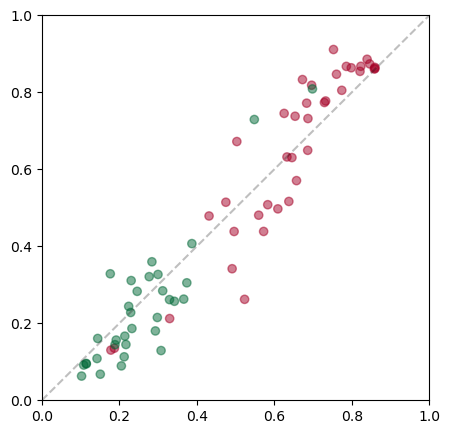

In [55]:
plt.figure(figsize=(5,5))
plt.scatter(
    y_predictions, y_predictions_no_structure,
    c=y_test, cmap="RdYlGn_r",
    alpha=.5
)
plt.plot([0,1],[0,1],"k--",alpha=.25)
plt.ylim(0, 1)
plt.xlim(0, 1)

/tmp/ipykernel_2340937/2405376855.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  c=y_test[np.argsort(y_predictions)], cmap="RdYlGn_r",
/tmp/ipykernel_2340937/2405376855.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  c=y_test[np.argsort(y_predictions)], cmap="RdYlGn_r",


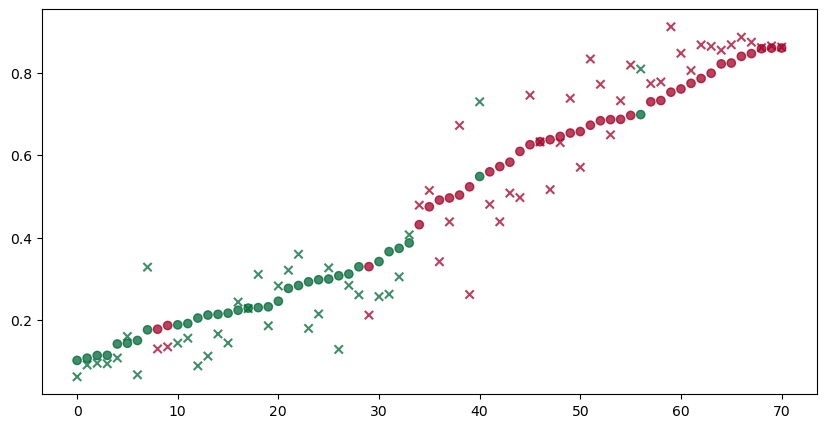

In [54]:
plt.figure(figsize=(10, 5))
plt.scatter(
    np.arange(len(y_test)),
    y_predictions[np.argsort(y_predictions)],
    c=y_test[np.argsort(y_predictions)], cmap="RdYlGn_r",
    alpha=.75
)
plt.scatter(
    np.arange(len(y_test)),
    y_predictions_no_structure[np.argsort(y_predictions)],
    c=y_test[np.argsort(y_predictions)], cmap="RdYlGn_r",
    alpha=.75, marker="x"
)
plt.show()

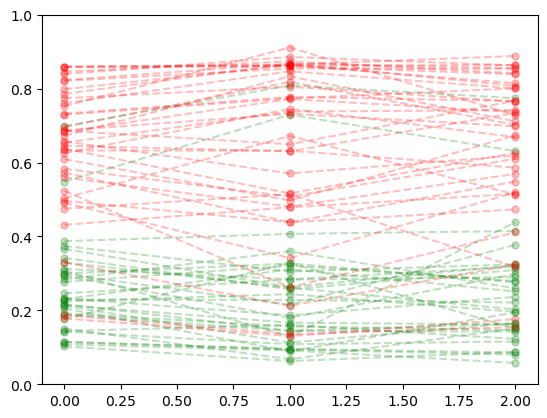

In [77]:
plt.plot(
    np.stack([y_predictions, y_predictions_no_structure, y_predictions_no_position, ])[:,y_test==0],
    linestyle="--", color="green", alpha=.25, marker="o", markersize=5
)
plt.plot(
    np.stack([y_predictions, y_predictions_no_structure, y_predictions_no_position, ])[:,y_test==1],
    linestyle="--", color="red", alpha=.25, marker="o", markersize=5
)
plt.ylim(0,1)
plt.show()

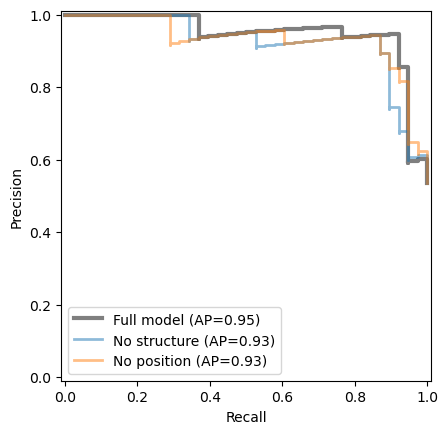

In [101]:
def plot_precision_recall(y_true, y_pred, **kwargs):
    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    disp = PrecisionRecallDisplay(precision=precision, recall=recall, **kwargs)
    return disp

ax = plt.subplot(111)

plot_precision_recall(
    y_test, y_predictions,
    estimator_name=f"Full model (AP={round(average_precision_score(y_test, y_predictions), 2)})"
).plot(ls="-", lw=3, alpha=.5, color="k", ax=ax)

plot_precision_recall(
    y_test, y_predictions_no_structure,
    estimator_name=f"No structure (AP={round(average_precision_score(y_test, y_predictions_no_structure), 2)})"
).plot(ls="-", lw=2, alpha=.5, ax=ax)

plot_precision_recall(
    y_test, y_predictions_no_position,
    estimator_name=f"No position (AP={round(average_precision_score(y_test, y_predictions_no_position), 2)})"
).plot(ls="-", lw=2, alpha=.5, ax=ax)

plt.show()

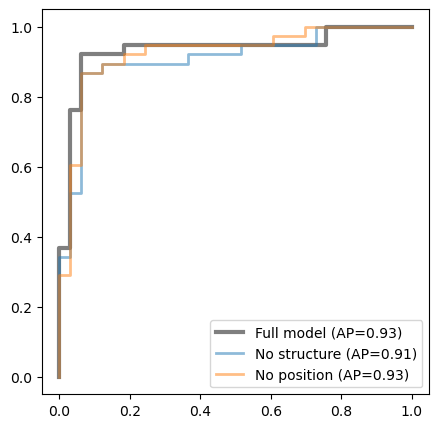

In [106]:
def plot_auroc(y_true, y_pred, **kwargs):
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    disp = plt.plot(fpr, tpr, **kwargs)
    return disp

plt.figure(figsize=(5,5))
ax = plt.subplot(111)

plot_auroc(
    y_test, y_predictions,
    label=f"Full model (AP={round(roc_auc_score(y_test, y_predictions), 2)})",
    ls="-", lw=3, alpha=.5, color="k"
)

plot_auroc(
    y_test, y_predictions_no_structure,
    label=f"No structure (AP={round(roc_auc_score(y_test, y_predictions_no_structure), 2)})",
    ls="-", lw=2, alpha=.5
)

plot_auroc(
    y_test, y_predictions_no_position,
    label=f"No position (AP={round(roc_auc_score(y_test, y_predictions_no_position), 2)})",
    ls="-", lw=2, alpha=.5
)
plt.legend()
plt.show()

In [109]:
stats.wilcoxon(
    (y_test - y_predictions)**2,
    (y_test - y_predictions_no_structure)**2
)

WilcoxonResult(statistic=1197.0, pvalue=0.6425641354127845)

In [110]:
stats.wilcoxon(
    (y_test - y_predictions)**2,
    (y_test - y_predictions_no_position)**2
)

WilcoxonResult(statistic=943.0, pvalue=0.05492171768257244)